In [1]:
!git config --global user.email "tasnimkhondoker1999.com"
!git config --global user.name "mim-1999"

In [2]:
from getpass import getpass
token = getpass('Enter GitHub token: ')

username = 'mim-1999'
repo = 'customer-churn-prediction'
!git clone https://{token}@github.com/{username}/{repo}.git
%cd customer-churn-prediction
!git pull origin main --no-rebase --no-edit

Enter GitHub token: ··········
Cloning into 'customer-churn-prediction'...
remote: Enumerating objects: 49, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 49 (delta 15), reused 19 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (49/49), 385.07 KiB | 6.75 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/customer-churn-prediction
From https://github.com/mim-1999/customer-churn-prediction
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
import pandas as pd
url = 'https://raw.githubusercontent.com/mim-1999/customer-churn-prediction/main/data/processed/telco_clean.csv'
df = pd.read_csv(url)

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
y_train.value_counts(normalize=True)

,proportion
Churn,
0,0.734647
1,0.265353


In [6]:
X_train.shape, X_test.shape, y_train.value_counts(normalize=True)

((5634, 26),
 (1409, 26),
 Churn
 0    0.734647
 1    0.265353
 Name: proportion, dtype: float64)

In [7]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [8]:
y_pred = model.predict(X_test)
y_pred_proba_churn = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba_churn))

[[844 191]
 [186 188]]
              precision    recall  f1-score   support

           0       0.82      0.82      0.82      1035
           1       0.50      0.50      0.50       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409

ROC-AUC: 0.6585858585858586


In [9]:
train_pred = model.predict(X_train)

from sklearn.metrics import accuracy_score
print('Train accuracy:', accuracy_score(y_train, train_pred))
print('Test accuracy:', accuracy_score(y_test, y_pred))

Train accuracy: 0.9980475683351083
Test accuracy: 0.7324343506032647


In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = range(1, 21)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    train_scores.append(train_acc)
    test_scores.append(test_acc)

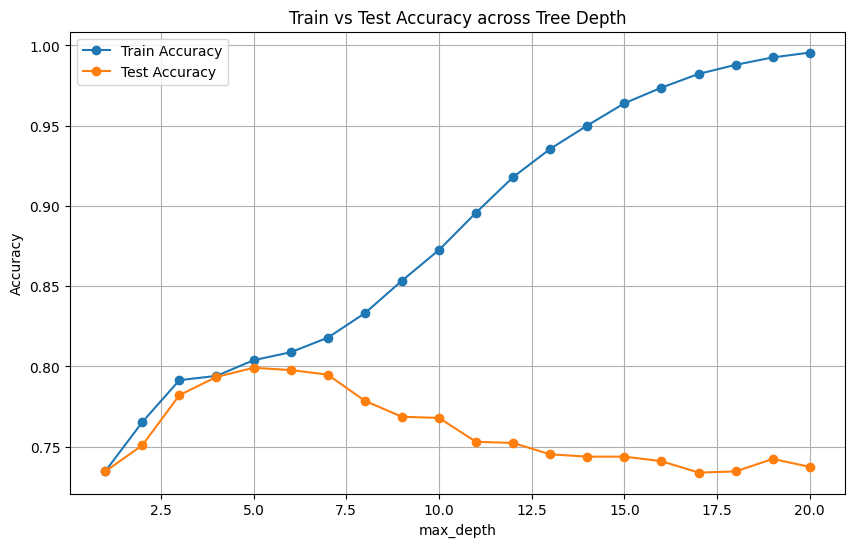

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy across Tree Depth')
plt.legend()
plt.grid(True)
plt.savefig('images/depth_tuning.png')
plt.show()

In [12]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba_churn2 = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba_churn2))

[[908 127]
 [156 218]]
              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1035
           1       0.63      0.58      0.61       374

    accuracy                           0.80      1409
   macro avg       0.74      0.73      0.74      1409
weighted avg       0.79      0.80      0.80      1409

ROC-AUC: 0.8343524761683329


In [13]:
model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba_churn3 = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_pred_proba_churn3))

[[769 266]
 [ 78 296]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.79      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.8353044511612286


In [14]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)
print(importances.head(10))

Contract_Month-to-month           0.605746
tenure                            0.110433
InternetService_Fiber optic       0.107517
MonthlyCharges                    0.053766
Contract_Two year                 0.025811
TotalCharges                      0.023746
PaymentMethod_Electronic check    0.019401
InternetService_No                0.014682
PhoneService                      0.013824
StreamingMovies                   0.012612
dtype: float64


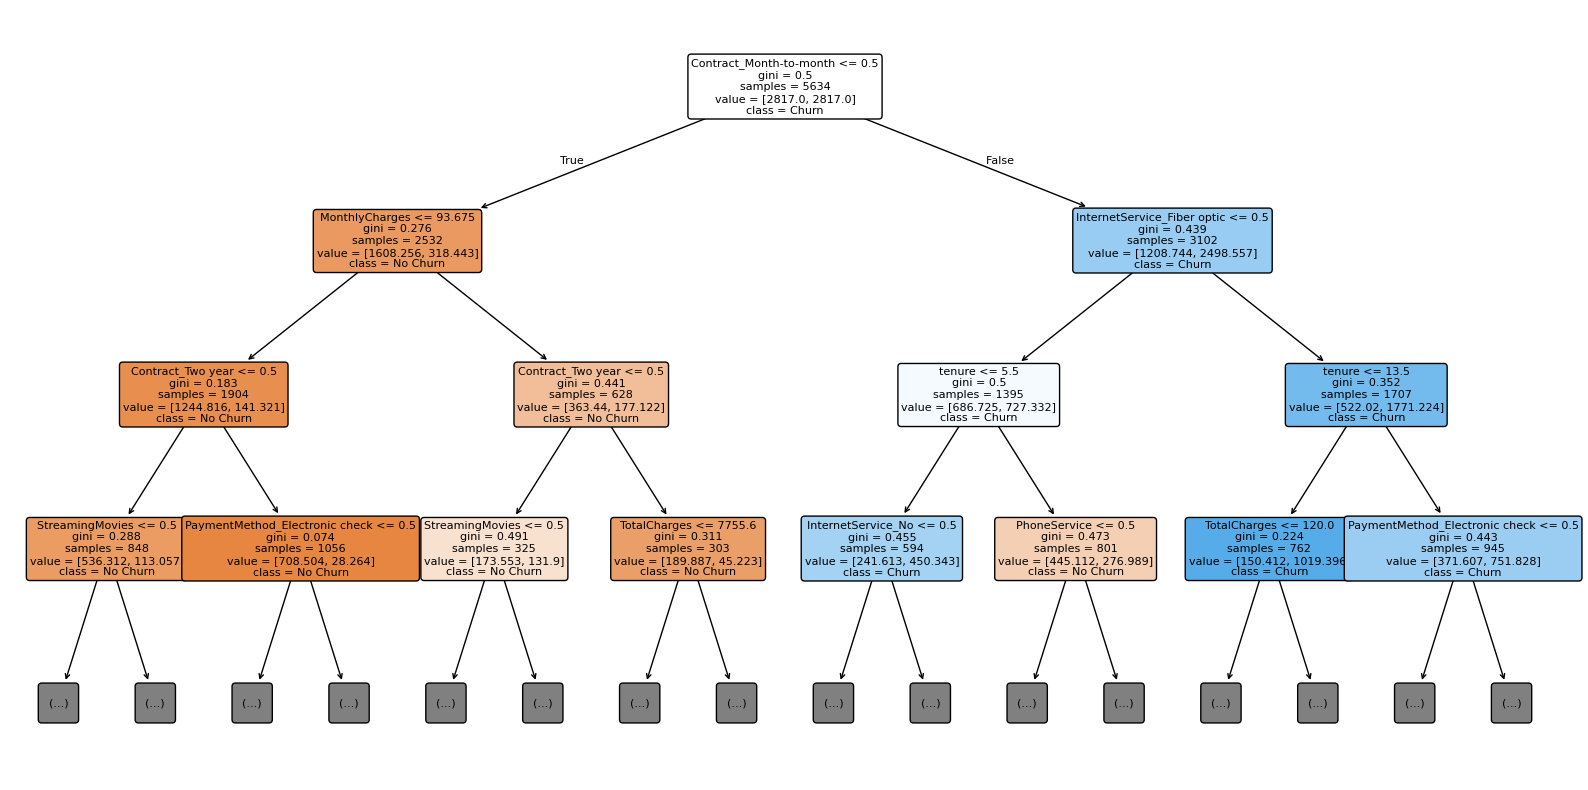

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=X_train.columns, class_names=['No Churn', 'Churn'],
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.savefig('images/decision_tree_plot.png', dpi=150, bbox_inches='tight')
plt.show()